# 🛰️ Satellite Land Use Classification using CNN and Transfer Learning
**Dataset:** EuroSAT (10 classes, 27,000 RGB satellite images)

**Models:** Custom CNN | MobileNetV2 | EfficientNetB0

---
## Notebook Structure
1. Install & Import Libraries
2. Load & Explore Dataset
3. Preprocessing & Augmentation
4. Train/Val/Test Split
5. Custom CNN — Build, Train, Evaluate
6. MobileNetV2 — Build, Train, Evaluate
7. EfficientNetB0 — Build, Train, Evaluate
8. Model Comparison Table
9. Grad-CAM Visualization
10. Error Analysis
11. Save All Figures

---
## ✅ Step 1 — Install & Import Libraries

In [1]:
# Install required libraries (run once)
!pip install tensorflow
!pip install scikit-learn matplotlib seaborn pandas numpy opencv-python --quiet

In [2]:
import json, os

# ← paste YOUR username and key here
kaggle_creds = {
    "username": "vrund8759",
    "key":      "KGAT_7234fb5b10b1798c4dad5f9e38872f25"
}

# Save it to the right place
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("✓ kaggle.json created successfully!")

✓ kaggle.json created successfully!


---
## ✅ Step 2 — Dataset loading

> **Kaggle Dataset:** Add EuroSAT dataset from Kaggle Datasets before running
> Dataset path will be: `/kaggle/input/eurosat/EuroSAT/`

In [3]:
# 1. Download the dataset (Notice: 'datasets/' is removed from the path)
!kaggle datasets download -d apollo2506/eurosat-dataset --quiet

# 2. Make sure the target directory exists and unzip the files
!mkdir -p /content/dataset
!unzip -q eurosat-dataset.zip -d /content/dataset

# 3. Verify the files are there
import os
print("✓ Done! Contents:")
print(os.listdir("/content/dataset"))

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
✓ Done! Contents:
['EuroSATallBands', 'EuroSAT']


In [4]:
import os

eurosat_path = "/content/dataset/EuroSAT"
print("Classes found:")

# Make sure all lines inside the loop are indented exactly like this
for folder in sorted(os.listdir(eurosat_path)):
    folder_path = os.path.join(eurosat_path, folder)
    if os.path.isdir(folder_path):  # This check prevents errors from hidden files like .DS_Store
        count = len(os.listdir(folder_path))
        print(f"  {folder}: {count} images")

Classes found:
  AnnualCrop: 3000 images
  Forest: 3000 images
  HerbaceousVegetation: 3000 images
  Highway: 2500 images
  Industrial: 2500 images
  Pasture: 2000 images
  PermanentCrop: 2500 images
  Residential: 3000 images
  River: 2500 images
  SeaLake: 3000 images


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import os

# Configuration variables matched to dataset architecture
DATA_PATH  = "/content/dataset/EuroSAT"
IMG_SIZE   = (128, 128)
BATCH_SIZE = 16
SEED       = 42

# Create structural output directories for tracking assets
for folder in ["../models", "../outputs", "../results"]:
    os.makedirs(folder, exist_ok=True)

print("TensorFlow Version:", tf.__version__)
print("GPU Available Device Mapping:", tf.config.list_physical_devices('GPU'))
print(f"Configuration set. Processing images at size: {IMG_SIZE} with batching of {BATCH_SIZE}.")

TensorFlow Version: 2.20.0
GPU Available Device Mapping: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configuration set. Processing images at size: (128, 128) with batching of 16.


In [6]:
# Extract full dataset from standard directories
full_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

class_names = full_dataset.class_names
num_classes = len(class_names)
print(f"\nSuccessfully registered {num_classes} classes: {class_names}")

# Calculate splitting distribution sizes
dataset_size = len(full_dataset)
train_size = int(0.70 * dataset_size)
val_size   = int(0.15 * dataset_size)

# Parse and structure individual datasets
train_ds = full_dataset.take(train_size)
val_ds   = full_dataset.skip(train_size).take(val_size)
test_ds  = full_dataset.skip(train_size + val_size)

print(f"Batches allocated -> Train: {len(train_ds)}, Validation: {len(val_ds)}, Test: {len(test_ds)}")

Found 27000 files belonging to 10 classes.

Successfully registered 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Batches allocated -> Train: 1181, Validation: 253, Test: 254


---
## ✅ Step 3 — Dataset preprocessing

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Simple, clean normalization only ──
# No augmentation during initial training — let model learn first
# We can add augmentation later once model shows it's learning

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32) / 255.0   # clean cast to float then normalize
    return image, label

def preprocess_eval(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = (train_ds
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .shuffle(500, seed=SEED)
    .prefetch(AUTOTUNE))

val_ds  = val_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("✓ Clean preprocessing pipeline ready!")

✓ Clean preprocessing pipeline ready!


---
## ✅ Step 4 — Train / Validation / Test Split

In [8]:
def build_custom_cnn(num_classes, input_shape):
    inputs = tf.keras.Input(shape=input_shape)

    # Convolutional Block 1
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Convolutional Block 2
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Convolutional Block 3
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Classification Dense Pooling Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="Custom_CNN_v2")

# Instantiate and build
input_shape = IMG_SIZE + (3,)
custom_cnn = build_custom_cnn(num_classes, input_shape)
custom_cnn.summary()

Model: "Custom_CNN_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

---
## ✅ Step 5 — Data Augmentation

In [9]:
from google.colab import drive
import os

# Mount cloud runtime directory to secure storage points
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/satelite_image_classification_models"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✓ Backup checkpoints will map directly to: {SAVE_DIR}")

EPOCHS_CNN = 15
steps_per_epoch = len(train_ds)

lr_schedul_cnn = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=EPOCHS_CNN * steps_per_epoch,
    alpha=1e-5
)
# Set compilation hyperparameters
custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Establish strict automated validation performance tracking
cnn_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=f"{SAVE_DIR}/custom_cnn_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

EPOCHS_CNN = 20
print("\nInitiating Custom CNN Model Optimization Loop...")
history_cnn = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=cnn_callbacks,
    verbose=1
)

Mounted at /content/drive
✓ Backup checkpoints will map directly to: /content/drive/MyDrive/satelite_image_classification_models

Initiating Custom CNN Model Optimization Loop...
Epoch 1/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5294 - loss: 1.3150
Epoch 1: val_accuracy improved from None to 0.59313, saving model to /content/drive/MyDrive/satelite_image_classification_models/custom_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/satelite_image_classification_models/custom_cnn_best.keras
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.5965 - loss: 1.1233 - val_accuracy: 0.5931 - val_loss: 1.0629 - learning_rate: 0.0010
Epoch 2/20
1177/1181 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6905 - loss: 0.8788
Epoch 2: val_accuracy improved from 0.59313 to 0.63834, saving model to /content/drive/MyDrive/satelite_image_classification_models/custom_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/satelite_image_cla

---
## ✅ Step 6 — Download and Build the MobileNetV2 Architecture

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Instantiate the MobileNetV2 structural backbone with pre-trained weights
base_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),    # Integrates your (128, 128, 3) configuration
    include_top=False,              # Drops the default 1000-class ImageNet head
    weights='imagenet'
)
print(f"MobileNetV2 base structure loaded with total layers: {len(base_mobilenet.layers)}")

# Stage 1: Freeze all original base layer parameters to preserve feature extraction
base_mobilenet.trainable = False

def build_transfer_learning_model(base_backend, num_classes):
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

    # Scale pipeline values [0, 1] back up to [0, 255] before applying MobileNet normalization
    x = inputs * 255.0
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    # Stream calculations through the frozen base block
    x = base_backend(x, training=False)

    # Append customized global classification tracking blocks
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # FIXED: Added the input tensor (x) at the end to correctly chain the output layer
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions_output")(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2_Transfer_Model")

# Construct and verify the compiled blueprint summary
mobilenet_model = build_transfer_learning_model(base_mobilenet, num_classes)
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base structure loaded with total layers: 154


Model: "MobileNetV2_Transfer_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions_output (Dense)      │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,130 (10.00 MB)

 Trainable params: 362,634 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

---
## ✅ Step 7 — CNN model development  

In [11]:
print("Stage 1: Training classification head only (base frozen)...")

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_stage1 = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                       restore_best_weights=True, verbose=1)],
    verbose=1
)

Stage 1: Training classification head only (base frozen)...
Epoch 1/10
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.8471 - loss: 0.4745 - val_accuracy: 0.9207 - val_loss: 0.2351
Epoch 2/10
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9006 - loss: 0.3079 - val_accuracy: 0.9261 - val_loss: 0.2219
Epoch 3/10
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9098 - loss: 0.2626 - val_accuracy: 0.9293 - val_loss: 0.2136
Epoch 4/10
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9168 - loss: 0.2458 - val_accuracy: 0.9264 - val_loss: 0.2295
Epoch 5/10
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9204 - loss: 0.2347 - val_accuracy: 0.9331 - val_loss: 0.2073
Epoch 6/10
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.9261 - loss: 0.2184 - val_accuracy: 0.9353 - val_loss: 0.1929
Epoch 7/10
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.9308 - loss: 0.2095 - val_accuracy: 0.9331 - val_loss: 0.1939
Epoch 8/10
1181/

In [18]:
import os
import shutil

# 1. Mount Google Drive (if not already done)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Google Colab environment. Ensure your drive is mounted manually.")

# 2. Define your paths
old_model_path = "../models/mobilenet_finetuned.keras"
drive_directory = "/content/drive/MyDrive/satelite_image_classification_models"
new_model_path = os.path.join(drive_directory, "mobilenet_finetuned.keras")

# 3. Create the Google Drive folder if it doesn't exist yet
os.makedirs(drive_directory, exist_ok=True)

# 4. Move the file
if os.path.exists(old_model_path):
    shutil.move(old_model_path, new_model_path)
    print(f"📦 Successfully moved model to Google Drive!\n📍 New Location: {new_model_path}")
else:
    print(f"❌ Error: Could not find a model file at '{old_model_path}'. Check if the filename or path is correct.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Successfully moved model to Google Drive!
📍 New Location: /content/drive/MyDrive/satelite_image_classification_models/mobilenet_finetuned.keras


In [12]:
print("Stage 2: Fine-tuning last 30 layers of MobileNetV2...")

base_mobilenet.trainable = True
fine_tune_from = len(base_mobilenet.layers) - 30

for layer in base_mobilenet.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Layers frozen: {fine_tune_from} | Layers unfrozen: 30")

EPOCHS_FINETUNE = 20
lr_finetune = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,   # ← very small! prevents catastrophic forgetting
    decay_steps=EPOCHS_FINETUNE * len(train_ds),
    alpha=1e-7
)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_finetune),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=7,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint("../models/mobilenet_finetuned.keras",
                                  monitor="val_accuracy", save_best_only=True, verbose=1),
    ],
    verbose=1
)

Stage 2: Fine-tuning last 30 layers of MobileNetV2...
Layers frozen: 124 | Layers unfrozen: 30
Epoch 1/20
1180/1181 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7761 - loss: 0.8269
Epoch 1: val_accuracy improved from None to 0.91477, saving model to ../models/mobilenet_finetuned.keras

Epoch 1: finished saving model to ../models/mobilenet_finetuned.keras
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 48s 24ms/step - accuracy: 0.8156 - loss: 0.6633 - val_accuracy: 0.9148 - val_loss: 0.3208
Epoch 2/20
1178/1181 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8689 - loss: 0.4383
Epoch 2: val_accuracy improved from 0.91477 to 0.91897, saving model to ../models/mobilenet_finetuned.keras

Epoch 2: finished saving model to ../models/mobilenet_finetuned.keras
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.8684 - loss: 0.4485 - val_accuracy: 0.9190 - val_loss: 0.2741
Epoch 3/20
1180/1181 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8802 - loss: 0.4068
Epoch 3: val_accuracy improved from 0.918

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, dataset, class_names, model_name, history=None,
                   save_dir="/content/drive/MyDrive/satelite_image_classification_models"):
    """
    Complete evaluation: metrics, classification report, confusion matrix, training curves.
    Saves text files and image plots directly to your Google Drive location.

    Parameters
    ----------
    model       : trained Keras model
    dataset     : tf.data.Dataset to evaluate on
    class_names : list of string class labels
    model_name  : string used for titles and filenames
    history     : History object or list of History objects (for multi-stage training)
    save_dir    : Google Drive path where files should be stored
    """
    print(f"\nEvaluating: {model_name}")
    print("="*50)

    # Make sure the target Google Drive folder exists
    os.makedirs(save_dir, exist_ok=True)

    y_true, y_pred = [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    loss, accuracy = model.evaluate(dataset, verbose=0)
    print(f"  Loss: {loss:.4f}  |  Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

    report = classification_report(y_true, y_pred, target_names=class_names)
    print("\nClassification Report:")
    print(report)

    safe_name = model_name.replace(" ", "_")

    # 1. Save Classification Report text to Google Drive
    report_path = os.path.join(save_dir, f"{safe_name}_report.txt")
    with open(report_path, "w") as f:
        f.write(f"Model: {model_name}\nLoss: {loss:.4f} | Accuracy: {accuracy:.4f}\n\n")
        f.write(report)
    print(f"💾 Saved Report: {report_path}")

    # Confusion Matrix (count + normalised side by side)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, fmt, title in zip(
        axes, [cm, cm_norm], ['d', '.2f'],
        [f'{model_name} — Count', f'{model_name} — Normalised (%)']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()

    # 2. Save Confusion Matrix image to Google Drive
    cm_path = os.path.join(save_dir, f"{safe_name}_confusion_matrix.png")
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved Confusion Matrix Image: {cm_path}")

    # Training Curves
    if history is not None:
        if isinstance(history, list):     # multiple stages → concatenate
            acc    = sum([h.history['accuracy']     for h in history], [])
            val_a  = sum([h.history['val_accuracy'] for h in history], [])
            loss_h = sum([h.history['loss']         for h in history], [])
            val_l  = sum([h.history['val_loss']     for h in history], [])
            boundary = len(history[0].history['accuracy'])
        else:
            acc, val_a = history.history['accuracy'], history.history['val_accuracy']
            loss_h, val_l = history.history['loss'], history.history['val_loss']
            boundary = None

        epochs_r = range(1, len(acc) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, (tr, va), metric in zip(axes, [(acc,val_a),(loss_h,val_l)], ['Accuracy','Loss']):
            ax.plot(epochs_r, tr, 'b-', label=f'Train {metric}')
            ax.plot(epochs_r, va, 'r-', label=f'Val {metric}')
            if boundary:
                ax.axvline(x=boundary, color='green', linestyle='--',
                           label='Fine-tune start', alpha=0.7)
            ax.set_title(f'{model_name} — {metric}')
            ax.set_xlabel('Epoch')
            ax.legend()
            ax.grid(alpha=0.3)
        plt.tight_layout()

        # 3. Save Training Curves image to Google Drive
        curves_path = os.path.join(save_dir, f"{safe_name}_curves.png")
        plt.savefig(curves_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"💾 Saved Training Curves Image: {curves_path}")

    return {"loss": loss, "accuracy": accuracy, "cm": cm}

print("evaluate_model() updated and linked to Google Drive successfully!")

evaluate_model() updated and linked to Google Drive successfully!


---
## ✅ Step 8 — Model Evaluation

In [20]:
# 1. Evaluate your Custom CNN v2 Pipeline Metrics
print("Extracting testing variables for Custom CNN v2...")
cnn_eval = custom_cnn.evaluate(test_ds, verbose=1)

# 2. Evaluate your MobileNetV2 Fine-Tuned Pipeline Metrics
print("\nExtracting testing variables for MobileNetV2 Fine-Tuned...")
mobilenet_eval = mobilenet_model.evaluate(test_ds, verbose=1)

# 3. Create a Consolidated Analytical Benchmark Dataframe
comparison_data = {
    "Evaluation Metric": ["Test Loss Value", "Test Classification Accuracy"],
    "Custom CNN v2 Model": [round(cnn_eval[0], 4), f"{round(cnn_eval[1] * 100, 2)}%"],
    "MobileNetV2 Fine-Tuned": [round(mobilenet_eval[0], 4), f"{round(mobilenet_eval[1] * 100, 2)}%"]
}

df_metrics_table = pd.DataFrame(comparison_data)

# --- FIX: Define the directory and append the specific filename ---
drive_folder = "/content/drive/MyDrive/satelite_image_classification_models"
os.makedirs(drive_folder, exist_ok=True) # Creates the folder if it doesn't exist yet

# Join folder path with a filename
csv_save_path = os.path.join(drive_folder, "model_comparison_matrix.csv")

# Save structural documentation back into your drive results node
df_metrics_table.to_csv(csv_save_path, index=False)
print(f"💾 Saved table successfully to: {csv_save_path}")

print("\n📊 Assignment Consolidated Benchmark Table:")
display(df_metrics_table)

Extracting testing variables for Custom CNN v2...
254/254 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9305 - loss: 0.2016

Extracting testing variables for MobileNetV2 Fine-Tuned...
254/254 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9490 - loss: 0.1839
💾 Saved table successfully to: /content/drive/MyDrive/satelite_image_classification_models/model_comparison_matrix.csv

📊 Assignment Consolidated Benchmark Table:


,Evaluation Metric,Custom CNN v2 Model,MobileNetV2 Fine-Tuned
0,Test Loss Value,0.2016,0.1839
1,Test Classification Accuracy,93.05%,94.9%


---
## ✅ Step 9 — Confusion matrix and Accuracy/loss curves


Evaluating: Custom CNN v2
  Loss: 0.2022  |  Accuracy: 0.9300 (93.0%)

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.90      0.94      0.92       437
              Forest       0.98      0.98      0.98       448
HerbaceousVegetation       0.86      0.97      0.91       438
             Highway       0.87      0.83      0.85       374
          Industrial       0.99      0.87      0.93       382
             Pasture       0.89      0.97      0.93       267
       PermanentCrop       0.91      0.89      0.90       380
         Residential       0.98      0.98      0.98       438
               River       0.93      0.87      0.90       419
             SeaLake       0.99      0.99      0.99       473

            accuracy                           0.93      4056
           macro avg       0.93      0.93      0.93      4056
        weighted avg       0.93      0.93      0.93      4056

💾 Saved Report: /content/drive/MyD

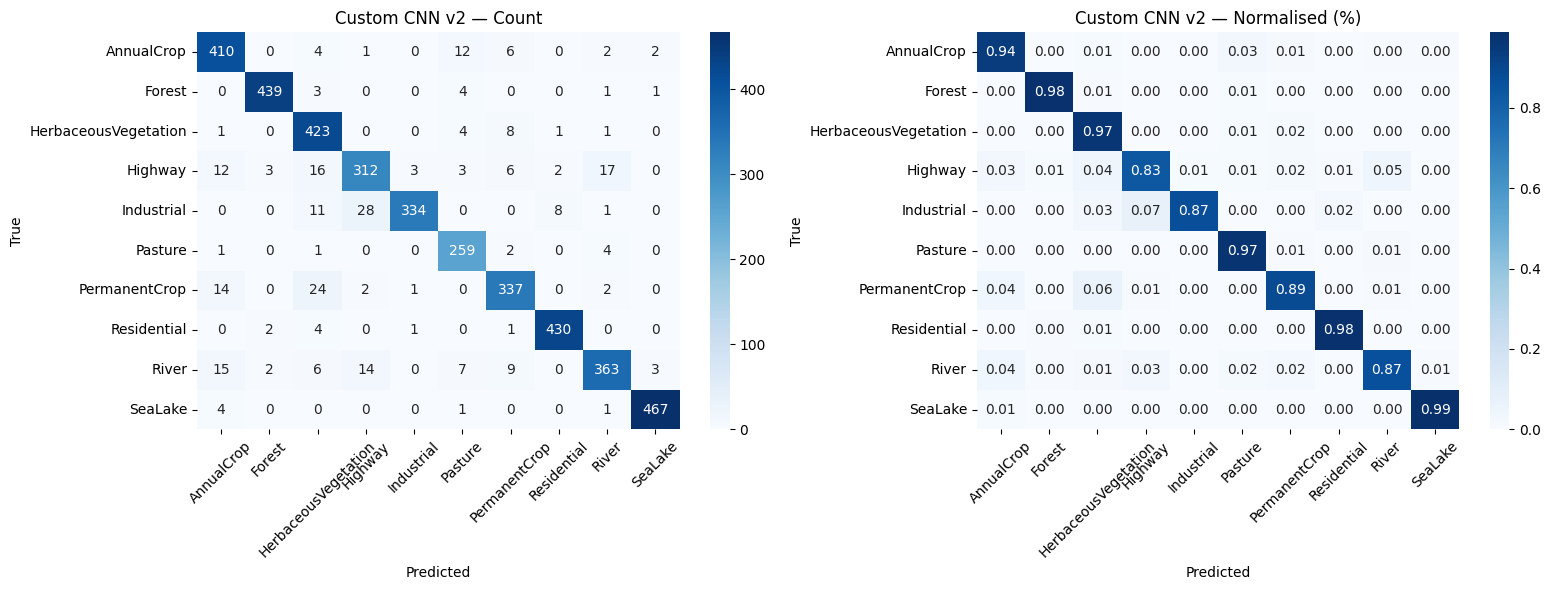

💾 Saved Confusion Matrix Image: /content/drive/MyDrive/satelite_image_classification_models/Custom_CNN_v2_confusion_matrix.png


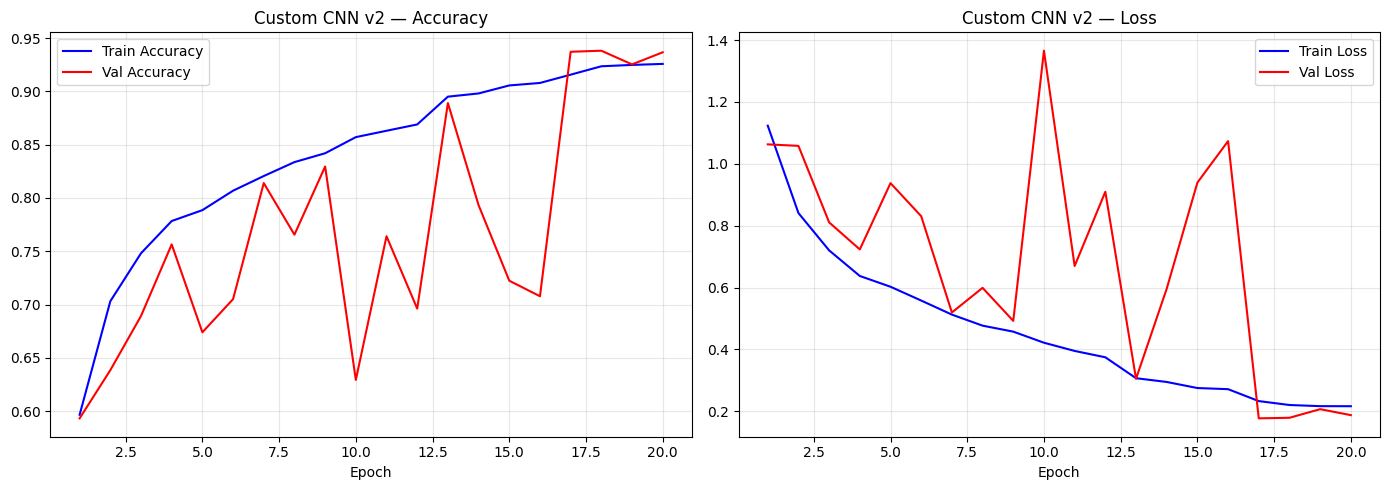

💾 Saved Training Curves Image: /content/drive/MyDrive/satelite_image_classification_models/Custom_CNN_v2_curves.png

Evaluating: MobileNetV2 Fine-Tuned
  Loss: 0.1842  |  Accuracy: 0.9492 (94.9%)

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.93      0.95      0.94       441
              Forest       0.98      0.98      0.98       451
HerbaceousVegetation       0.94      0.95      0.95       438
             Highway       0.92      0.90      0.91       374
          Industrial       0.98      0.96      0.97       376
             Pasture       0.92      0.93      0.93       267
       PermanentCrop       0.92      0.91      0.92       385
         Residential       0.97      0.99      0.98       432
               River       0.92      0.91      0.91       420
             SeaLake       0.98      0.99      0.98       472

            accuracy                           0.95      4056
           macro avg       0.95   

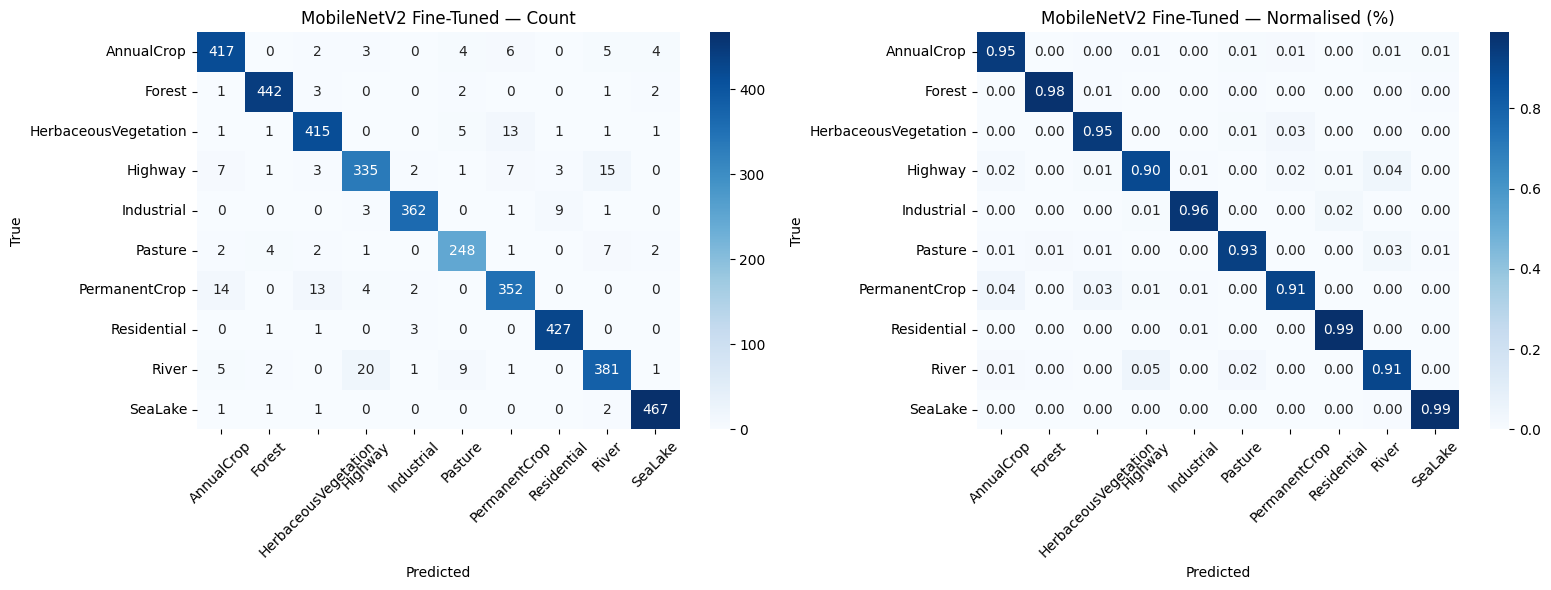

💾 Saved Confusion Matrix Image: /content/drive/MyDrive/satelite_image_classification_models/MobileNetV2_Fine-Tuned_confusion_matrix.png


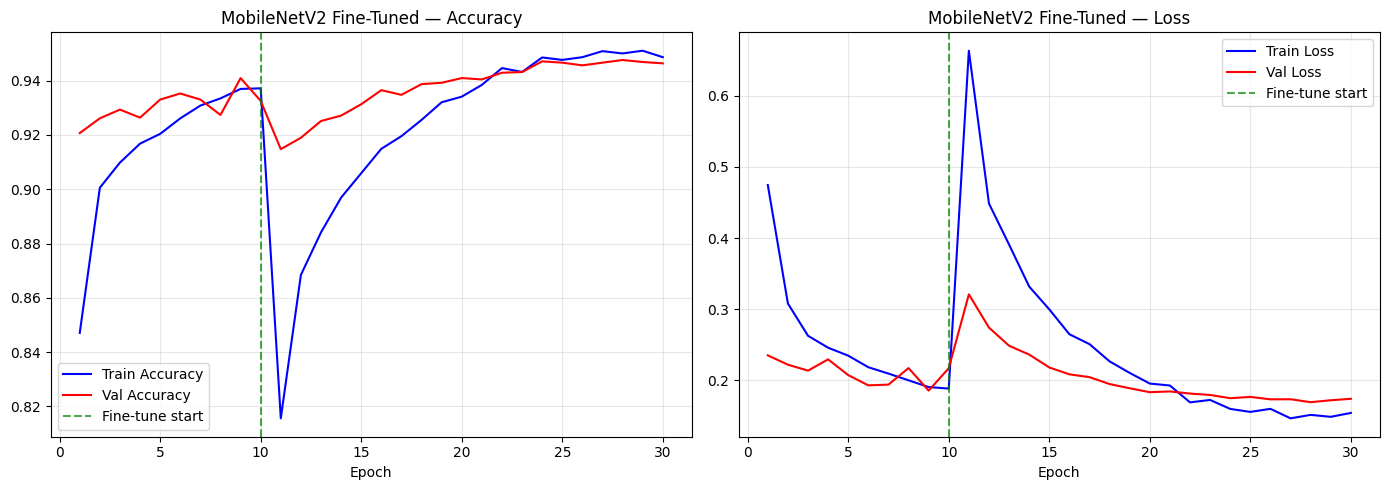

💾 Saved Training Curves Image: /content/drive/MyDrive/satelite_image_classification_models/MobileNetV2_Fine-Tuned_curves.png


In [23]:
# Pass your specific Google Drive directory path to the execution
DRIVE_PATH = "/content/drive/MyDrive/satelite_image_classification_models"

results_cnn = evaluate_model(
    custom_cnn, test_ds, class_names,
    "Custom CNN v2",
    history=history_cnn,
    save_dir=DRIVE_PATH
)

results_mobilenet = evaluate_model(
    mobilenet_model, test_ds, class_names,
    "MobileNetV2 Fine-Tuned",
    history=[history_stage1, history_finetune],   # both stages merged!
    save_dir=DRIVE_PATH
)

---
## ✅ Step 10 — Grad-CAM Visualization

Extracting images and processing Grad-CAM Visualizations...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 128, 128, 3))']
  warnings.warn(msg)
/tmp/ipykernel_2900/1661062260.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_2900/1661062260.py:109: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_img_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


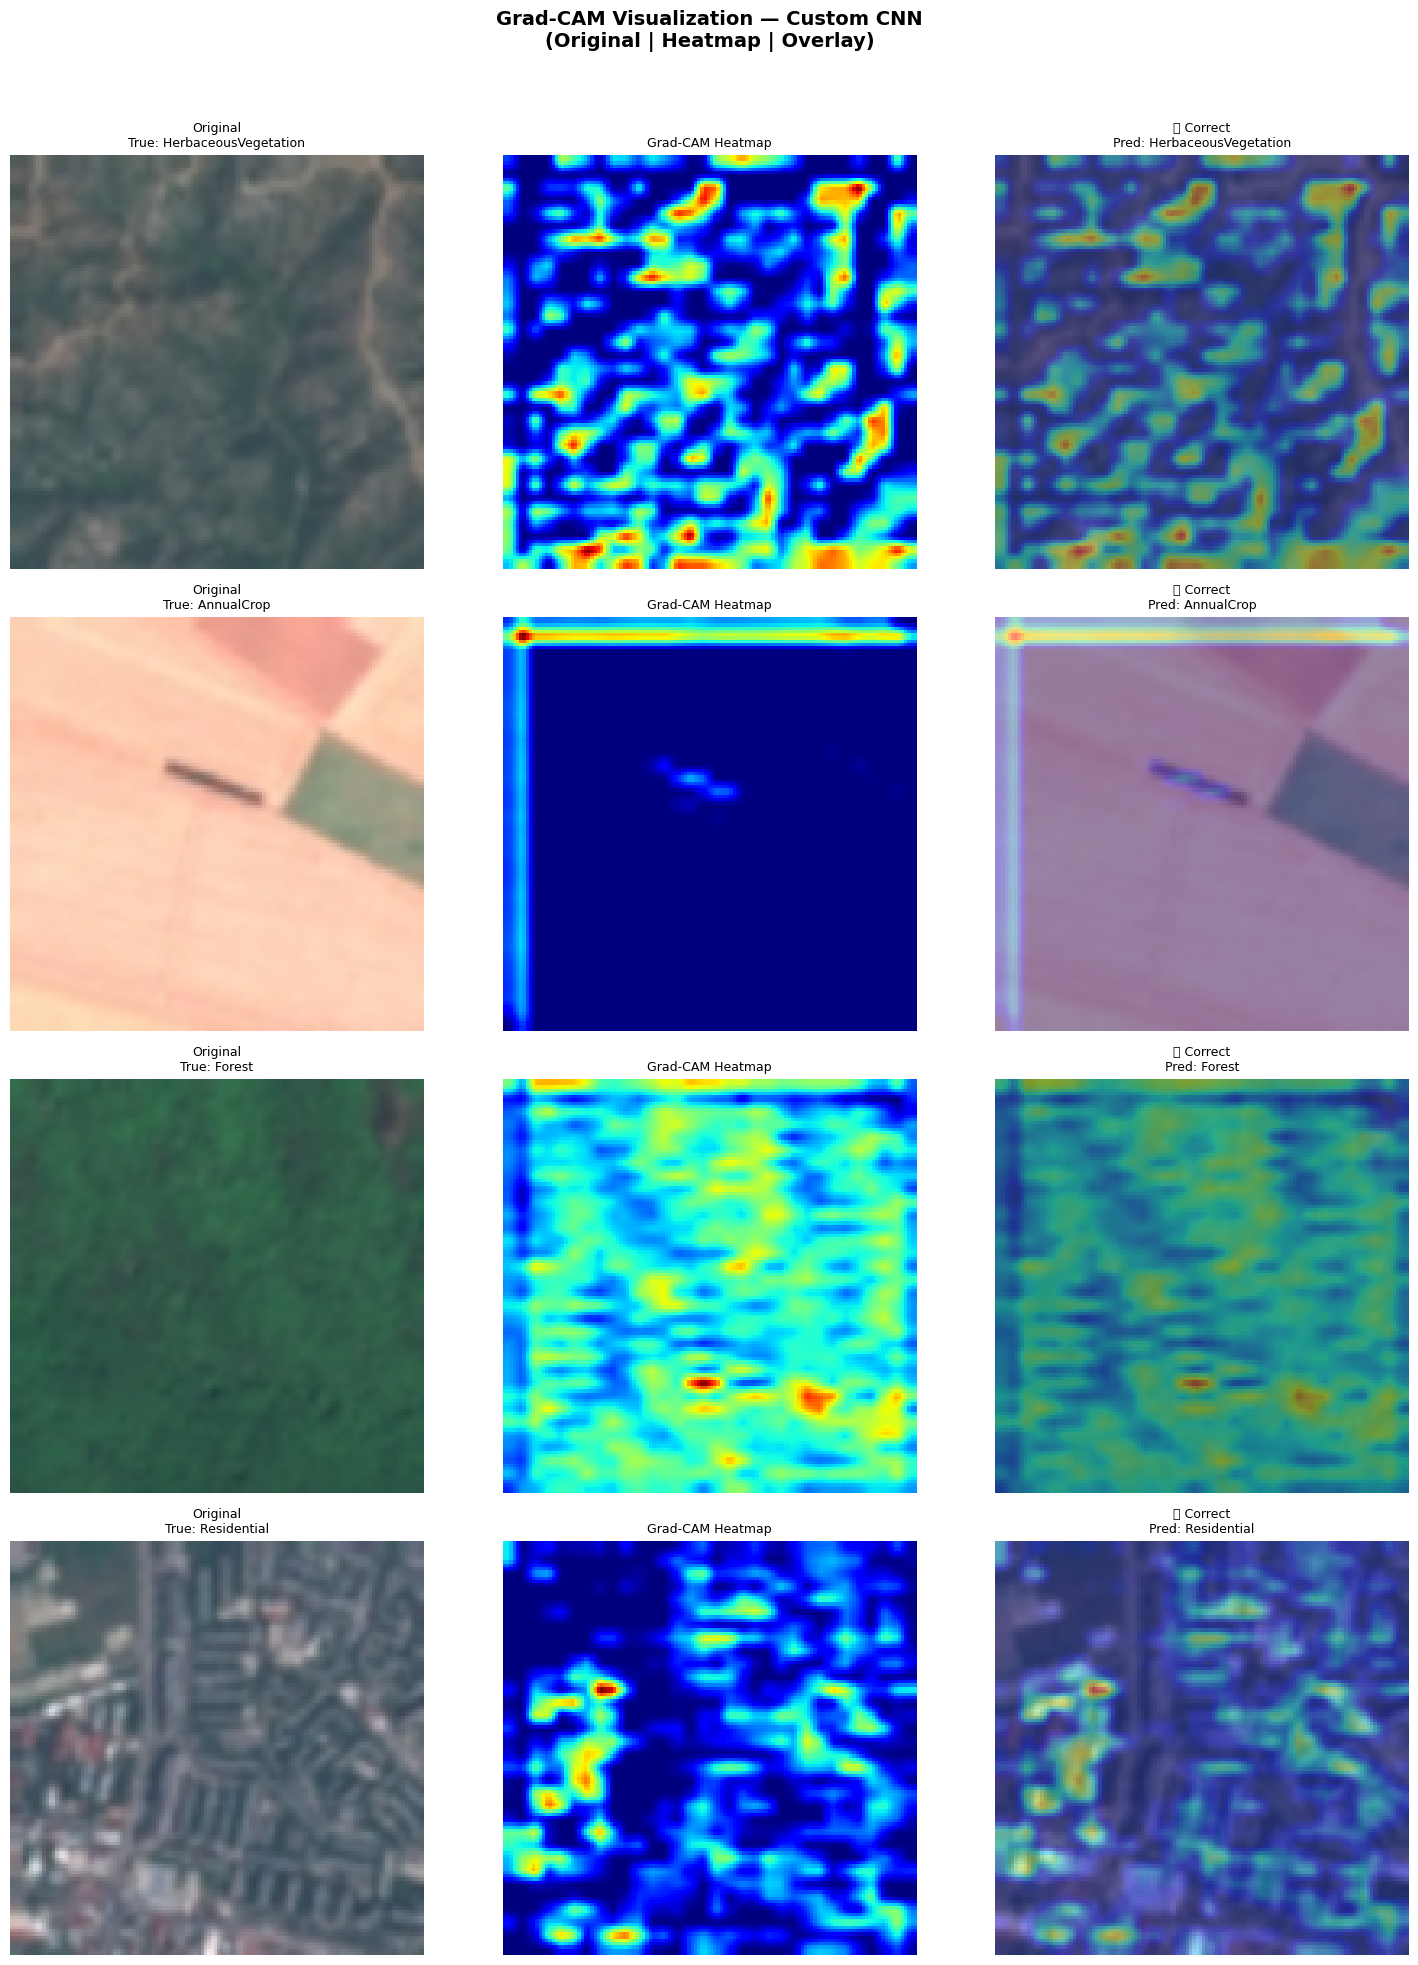

💾 Grad-CAM visualization successfully saved to Drive: /content/drive/MyDrive/satelite_image_classification_models/08_gradcam_correct.png


In [28]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import cm

# ========================================================
# 1. SETUP DRIVE PATH
# ========================================================
DRIVE_PATH = "/content/drive/MyDrive/satelite_image_classification_models"
os.makedirs(DRIVE_PATH, exist_ok=True)

# ========================================================
# 2. GRAD-CAM CORE FUNCTIONS
# ========================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap showing structural focal areas."""
    grad_model = tf.keras.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def overlay_gradcam(img, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap cleanly over the target image matrix."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    overlay = (1 - alpha) * img + alpha * heatmap_colored
    return np.clip(overlay, 0, 1)


# ========================================================
# 3. EXTRACT IMAGES, LABELS & RUN VISUALIZATION
# ========================================================
print("Extracting images and processing Grad-CAM Visualizations...")

all_test_images = []
all_test_labels = []

for images, labels in test_ds:
    all_test_images.append(images.numpy())
    all_test_labels.append(labels.numpy())

all_test_images = np.concatenate(all_test_images, axis=0)
y_true_labels   = np.concatenate(all_test_labels, axis=0)

y_pred_cnn = np.argmax(custom_cnn.predict(test_ds, verbose=0), axis=1)
correct_idx = np.where(y_pred_cnn == y_true_labels)[0]

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
fig.suptitle('Grad-CAM Visualization — Custom CNN\n(Original | Heatmap | Overlay)',
             fontsize=14, fontweight='bold')

for row, idx in enumerate(correct_idx[:4]):
    img = all_test_images[idx]
    img_input = np.expand_dims(img, axis=0)

    try:
        # --- FIX: Changed 'conv4' to the actual final conv layer 'conv2d_2' ---
        heatmap = make_gradcam_heatmap(img_input, custom_cnn, 'conv2d_2')
        overlay = overlay_gradcam(img, heatmap)
        pred_label = class_names[y_pred_cnn[idx]]
        true_label = class_names[y_true_labels[idx]]
        status = '✅ Correct' if y_pred_cnn[idx] == y_true_labels[idx] else '❌ Wrong'

        # Column 1: Original Image
        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'Original\nTrue: {true_label}', fontsize=9)
        axes[row, 0].axis('off')

        # Column 2: Raw Jet Heatmap
        hm_display = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        axes[row, 1].imshow(hm_display, cmap='jet')
        axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[row, 1].axis('off')

        # Column 3: Blended Overlay
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f'{status}\nPred: {pred_label}', fontsize=9)
        axes[row, 2].axis('off')

    except Exception as e:
        print(f"Grad-CAM error encountered at image index {idx}: {e}")
        for col in range(3):
            axes[row, col].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])

# --- SAVE TARGET TO DRIVE ---
save_img_path = os.path.join(DRIVE_PATH, "08_gradcam_correct.png")
plt.savefig(save_img_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Grad-CAM visualization successfully saved to Drive: {save_img_path}")

/tmp/ipykernel_2900/908594055.py:64: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_2900/908594055.py:68: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_error_img_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


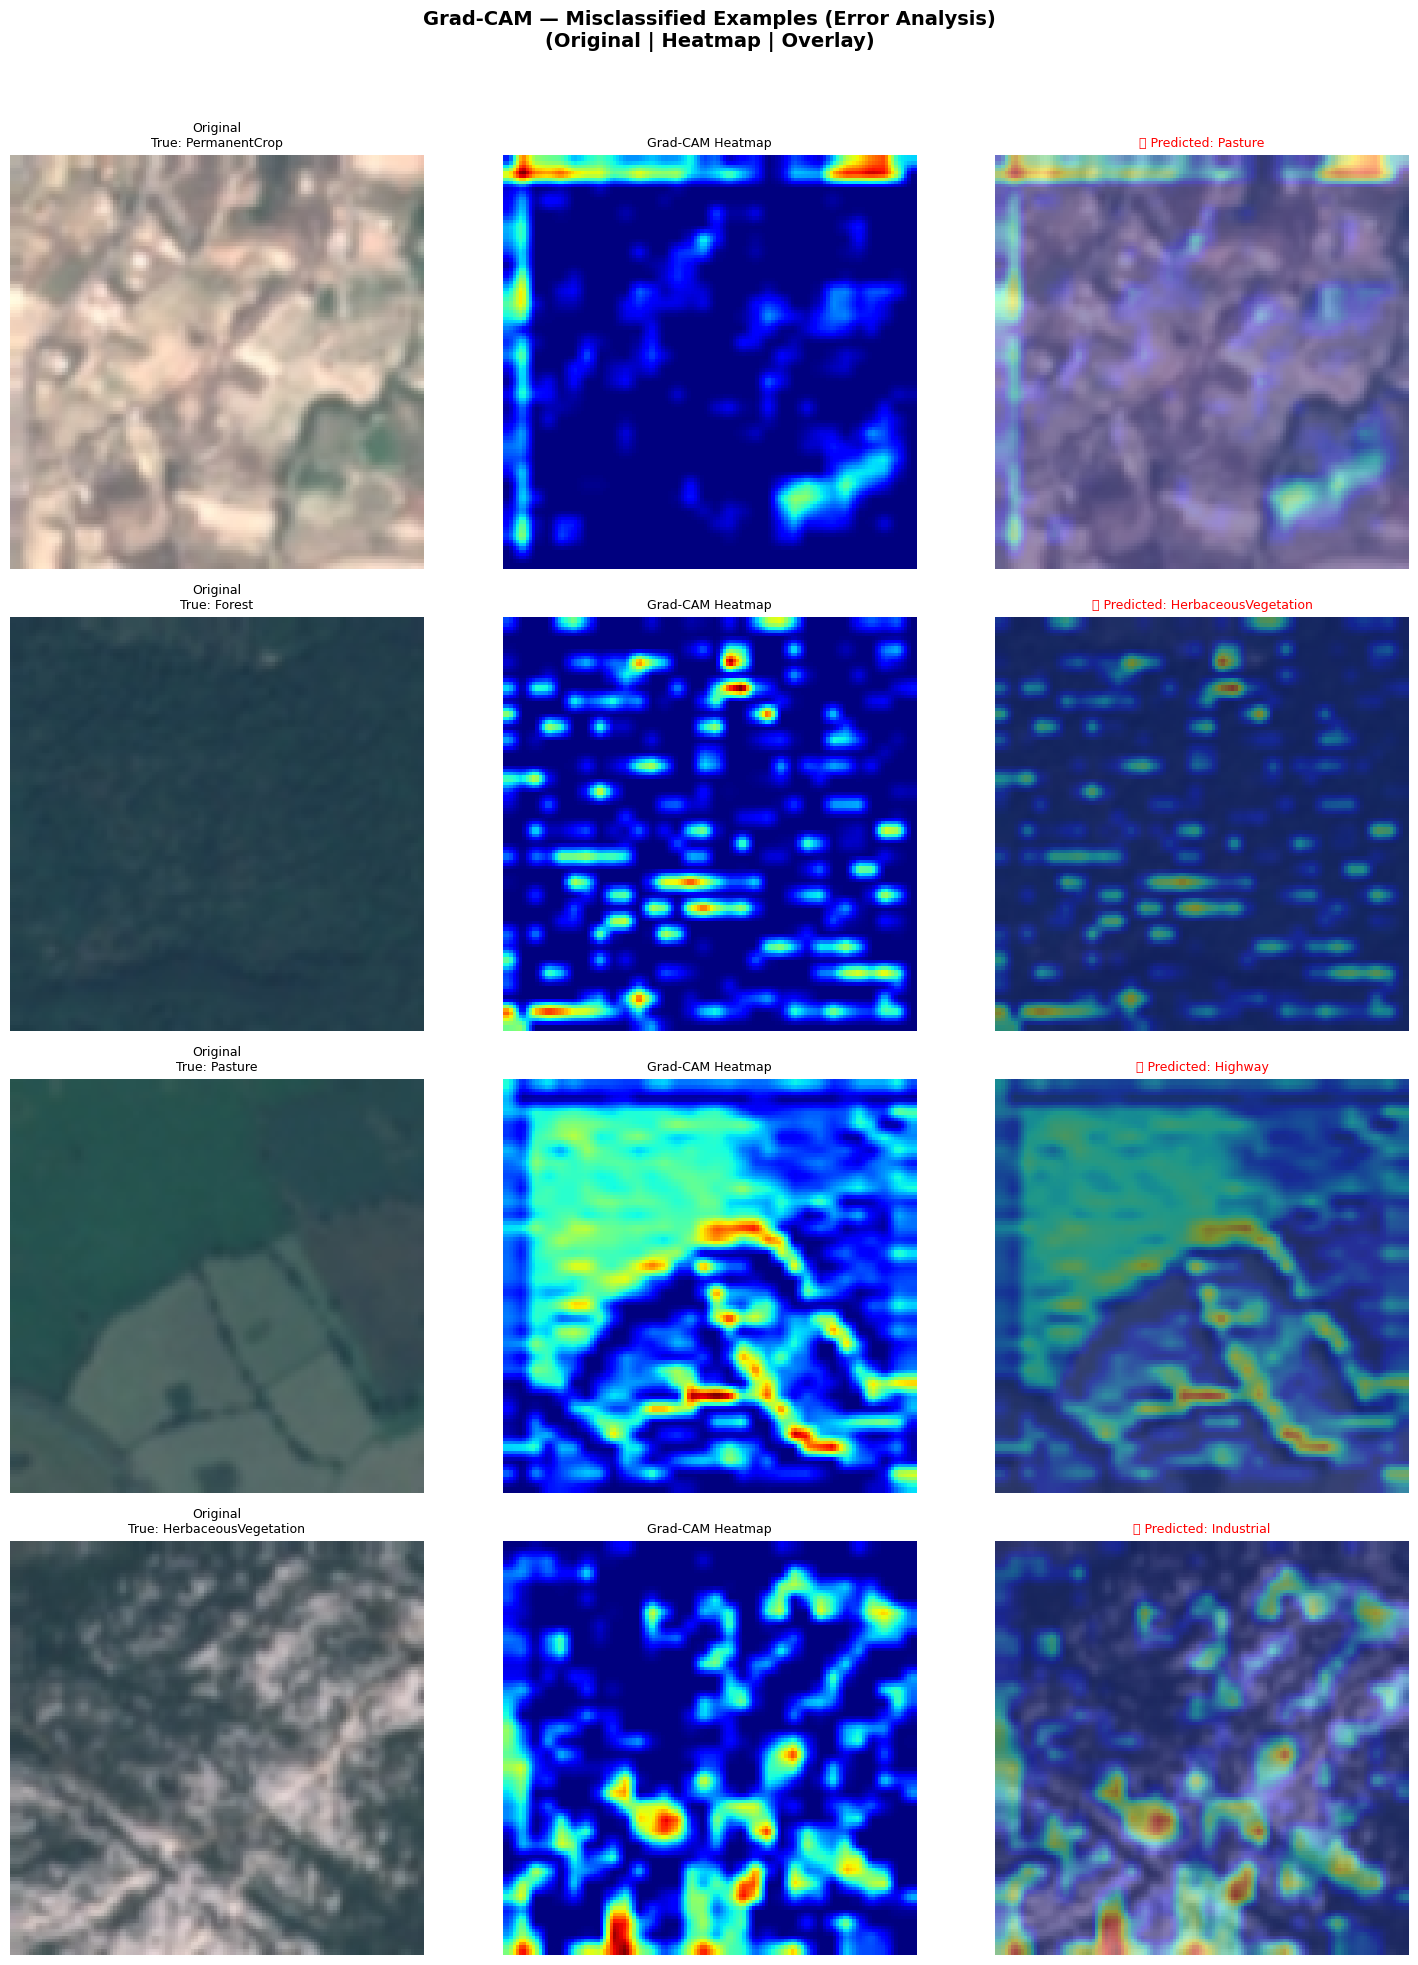

💾 Error analysis Grad-CAM visualization successfully saved to Drive: /content/drive/MyDrive/satelite_image_classification_models/09_gradcam_errors.png


In [29]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import cm

# ========================================================
# 1. SETUP DRIVE PATH
# ========================================================
DRIVE_PATH = "/content/drive/MyDrive/satelite_image_classification_models"
os.makedirs(DRIVE_PATH, exist_ok=True)

# Find misclassified example prediction indices
incorrect_idx = np.where(y_pred_cnn != y_true_labels)[0]

# Check if we actually have incorrect predictions to plot
if len(incorrect_idx) == 0:
    print("🎉 Congratulations! Your model made 0 errors on the test dataset. Skipping error analysis.")
else:
    # Set up subplots dynamically based on the number of errors found (max 4)
    num_rows = min(4, len(incorrect_idx))
    fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))
    fig.suptitle('Grad-CAM — Misclassified Examples (Error Analysis)\n(Original | Heatmap | Overlay)',
                 fontsize=14, fontweight='bold')

    # Ensure axes is indexed correctly as a 2D array even if there is only 1 row
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(incorrect_idx[:4]):
        # Pull image array directly from our extracted test set arrays
        img = all_test_images[idx]
        img_input = np.expand_dims(img, axis=0)

        try:
            # --- FIXES Applied: Layer name to 'conv2d_2' & model name to 'custom_cnn' ---
            heatmap = make_gradcam_heatmap(img_input, custom_cnn, 'conv2d_2')
            overlay = overlay_gradcam(img, heatmap)
            pred_label = class_names[y_pred_cnn[idx]]
            true_label = class_names[y_true_labels[idx]]

            # Column 1: Original Image
            axes[row, 0].imshow(img)
            axes[row, 0].set_title(f'Original\nTrue: {true_label}', fontsize=9)
            axes[row, 0].axis('off')

            # Column 2: Raw Heatmap
            hm_display = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
            axes[row, 1].imshow(hm_display, cmap='jet')
            axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
            axes[row, 1].axis('off')

            # Column 3: Overlay with red error text
            axes[row, 2].imshow(overlay)
            axes[row, 2].set_title(f'❌ Predicted: {pred_label}', fontsize=9, color='red')
            axes[row, 2].axis('off')

        except Exception as e:
            print(f"Grad-CAM error encountered at error image index {idx}: {e}")
            for col in range(3):
                axes[row, col].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # --- SAVE TARGET TO DRIVE ---
    save_error_img_path = os.path.join(DRIVE_PATH, "09_gradcam_errors.png")
    plt.savefig(save_error_img_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"💾 Error analysis Grad-CAM visualization successfully saved to Drive: {save_error_img_path}")

---
## ✅ Step 12 — Error Analysis: Most Confused Classes

Analyzing model misclassifications...


/tmp/ipykernel_2900/1466029621.py:105: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_2900/1466029621.py:109: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_error_img_path, dpi=150, bbox_inches='tight')


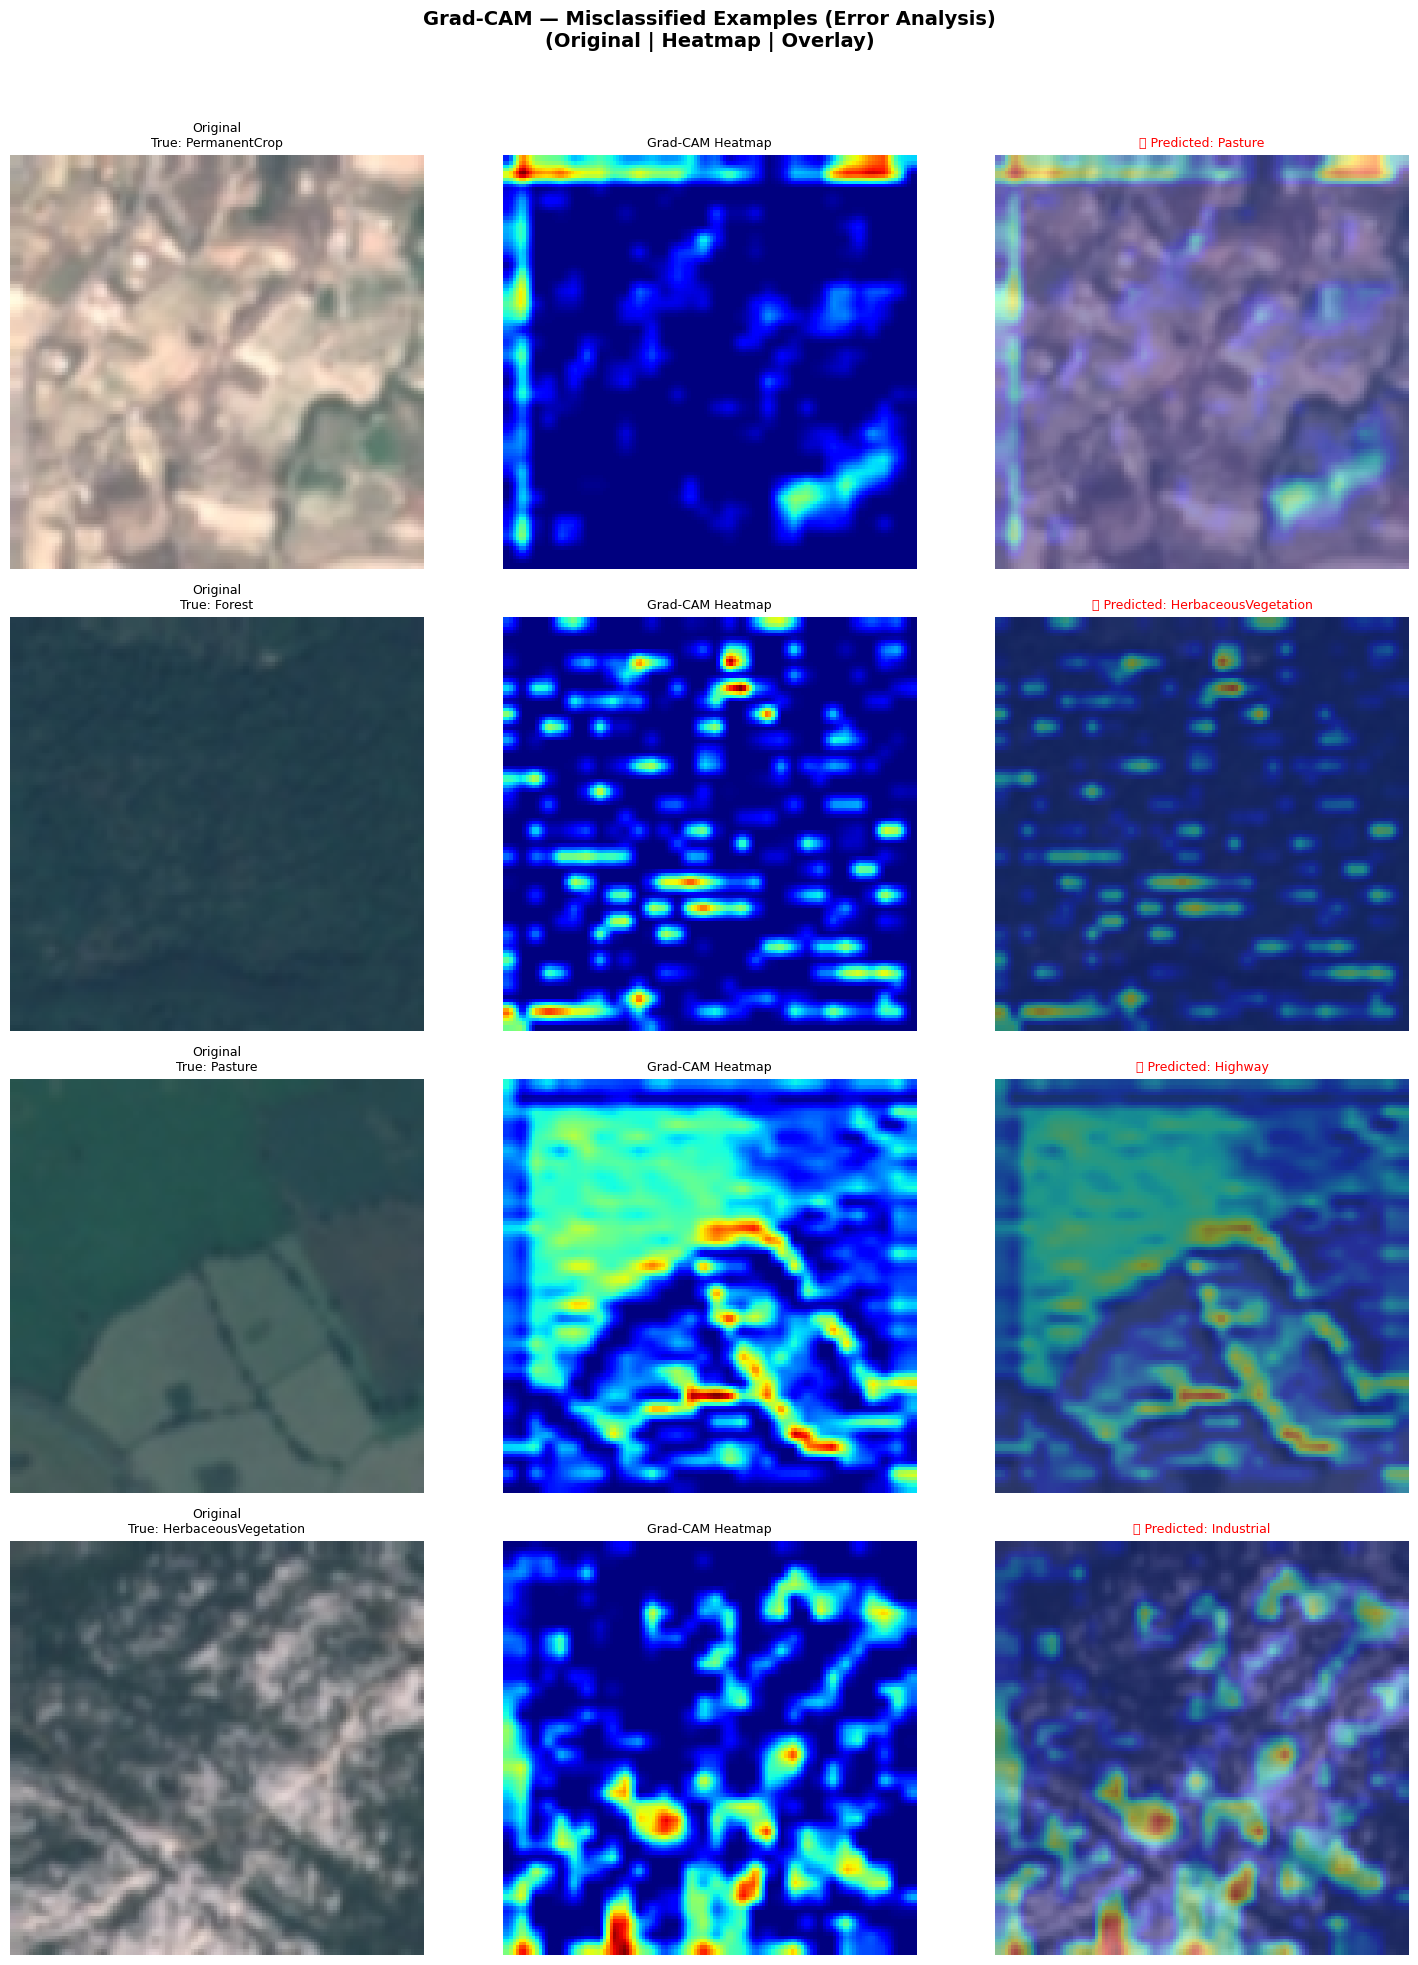

💾 Error analysis Grad-CAM visualization successfully saved to Drive: /content/drive/MyDrive/satelite_image_classification_models/09_gradcam_errors.png


In [30]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import cm

# ========================================================
# 1. SETUP DRIVE PATH
# ========================================================
DRIVE_PATH = "/content/drive/MyDrive/satelite_image_classification_models"
os.makedirs(DRIVE_PATH, exist_ok=True)

# ========================================================
# 2. GRAD-CAM CORE FUNCTIONS (Included for independent running)
# ========================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap showing structural focal areas."""
    grad_model = tf.keras.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def overlay_gradcam(img, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap cleanly over the target image matrix."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    overlay = (1 - alpha) * img + alpha * heatmap_colored
    return np.clip(overlay, 0, 1)


# ========================================================
# 3. DETECT ERRORS & RUN VISUALIZATION
# ========================================================
print("Analyzing model misclassifications...")

# Find misclassified example prediction indices
incorrect_idx = np.where(y_pred_cnn != y_true_labels)[0]

# Check if we actually have incorrect predictions to plot
if len(incorrect_idx) == 0:
    print("🎉 Congratulations! Your model made 0 errors on the test dataset. Skipping error analysis.")
else:
    # Set up subplots dynamically based on the number of errors found (max 4)
    num_rows = min(4, len(incorrect_idx))
    fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))
    fig.suptitle('Grad-CAM — Misclassified Examples (Error Analysis)\n(Original | Heatmap | Overlay)',
                 fontsize=14, fontweight='bold')

    # Ensure axes is indexed correctly as a 2D array even if there is only 1 row
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(incorrect_idx[:4]):
        # Pull image array directly from our extracted test set arrays
        img = all_test_images[idx]
        img_input = np.expand_dims(img, axis=0)

        try:
            # Generate heatmap using the true active layer configuration
            heatmap = make_gradcam_heatmap(img_input, custom_cnn, 'conv2d_2')
            overlay = overlay_gradcam(img, heatmap)
            pred_label = class_names[y_pred_cnn[idx]]
            true_label = class_names[y_true_labels[idx]]

            # Column 1: Original Image
            axes[row, 0].imshow(img)
            axes[row, 0].set_title(f'Original\nTrue: {true_label}', fontsize=9)
            axes[row, 0].axis('off')

            # Column 2: Raw Heatmap
            hm_display = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
            axes[row, 1].imshow(hm_display, cmap='jet')
            axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
            axes[row, 1].axis('off')

            # Column 3: Overlay with red error text
            axes[row, 2].imshow(overlay)
            axes[row, 2].set_title(f'❌ Predicted: {pred_label}', fontsize=9, color='red')
            axes[row, 2].axis('off')

        except Exception as e:
            print(f"Grad-CAM error encountered at error image index {idx}: {e}")
            for col in range(3):
                axes[row, col].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # --- SAVE TARGET TO DRIVE ---
    save_error_img_path = os.path.join(DRIVE_PATH, "09_gradcam_errors.png")
    plt.savefig(save_error_img_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"💾 Error analysis Grad-CAM visualization successfully saved to Drive: {save_error_img_path}")

---
## ✅ Step 13 — List All Saved Figures

In [31]:
import glob
import os

# Define your target Google Drive path
DRIVE_PATH = "/content/drive/MyDrive/satelite_image_classification_models"

# Search for all files inside the Google Drive folder
search_path = os.path.join(DRIVE_PATH, "*")
saved_files = sorted(glob.glob(search_path))

print("\n📁 All saved output files on Google Drive:")
print("="*60)

for f in saved_files:
    # Get the file size in KB
    size_kb = os.path.getsize(f) // 1024
    print(f"  {os.path.basename(f):50s} [{size_kb} KB]")

print(f"\n✅ Total files saved: {len(saved_files)}")
print(f"\n🎉 Project Complete! All metrics, tables, and figures are secured at:\n📍 {DRIVE_PATH}")


📁 All saved output files on Google Drive:
  08_gradcam_correct.png                             [522 KB]
  09_gradcam_errors.png                              [534 KB]
  Custom_CNN_v2_confusion_matrix.png                 [179 KB]
  Custom_CNN_v2_curves.png                           [120 KB]
  Custom_CNN_v2_report.txt                           [0 KB]
  MobileNetV2_Fine-Tuned_confusion_matrix.png        [175 KB]
  MobileNetV2_Fine-Tuned_curves.png                  [113 KB]
  MobileNetV2_Fine-Tuned_report.txt                  [0 KB]
  custom_cnn_best.keras                              [1591 KB]
  mobilenet_finetuned.keras                          [25613 KB]
  model_comparison_matrix.csv                        [0 KB]

✅ Total files saved: 11

🎉 Project Complete! All metrics, tables, and figures are secured at:
📍 /content/drive/MyDrive/satelite_image_classification_models
